In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [8]:
# criando lista de dados
letras = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
numeros = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
booleanos = [True, False, np.nan, True, False, np.nan, True, False, np.nan, True]
len(letras) == len(numeros) == len(booleanos)

True

In [10]:
dict_pratica = {
    'letras': letras,
    'numeros': numeros,
    'booleanos': booleanos
}
dict_pratica

{'letras': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
 'numeros': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'booleanos': [True, False, nan, True, False, nan, True, False, nan, True]}

In [13]:
#converter isso para um dataframe
df = pd.DataFrame(dict_pratica)
df

,letras,numeros,booleanos
0,A,1,True
1,B,2,False
2,C,3,NaN
3,D,4,True
4,E,5,False
5,F,6,NaN
6,G,7,True
7,H,8,False
8,I,9,NaN
9,J,10,True


In [16]:
valores = {
    "valores": np.random.randint(0,100, size=7),
    "letras": [i for i in "ABEFGIJ"]
}
df2 = pd.DataFrame(valores)
df2

,valores,letras
0,31,A
1,73,B
2,8,E
3,54,F
4,56,G
5,79,I
6,51,J


In [24]:
#fazer merge das duas dataframes
df_merge = pd.merge(df, df2, on="letras", how="inner")
df_merge

,letras,numeros,booleanos,valores
0,A,1,True,31
1,B,2,False,73
2,E,5,False,8
3,F,6,NaN,54
4,G,7,True,56
5,I,9,NaN,79
6,J,10,True,51


In [22]:
df.merge(df2, on="letras", how="left")
#utilizando o parametro how para definir o tipo de função

,letras,numeros,booleanos,valores
0,A,1,True,31.0
1,B,2,False,73.0
2,C,3,NaN,NaN
3,D,4,True,NaN
4,E,5,False,8.0
5,F,6,NaN,54.0
6,G,7,True,56.0
7,H,8,False,NaN
8,I,9,NaN,79.0
9,J,10,True,51.0


In [21]:
#juntar por concatenação
pd.concat([df, df2], axis=0)

,letras,numeros,booleanos,valores
0,A,1.0,True,NaN
1,B,2.0,False,NaN
2,C,3.0,NaN,NaN
3,D,4.0,True,NaN
4,E,5.0,False,NaN
5,F,6.0,NaN,NaN
6,G,7.0,True,NaN
7,H,8.0,False,NaN
8,I,9.0,NaN,NaN
9,J,10.0,True,NaN


In [26]:
df.head()

,letras,numeros,booleanos
0,A,1,True
1,B,2,False
2,C,3,NaN
3,D,4,True
4,E,5,False


In [27]:
df.tail()

,letras,numeros,booleanos
5,F,6,NaN
6,G,7,True
7,H,8,False
8,I,9,NaN
9,J,10,True


In [28]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   letras     10 non-null     object
 1   numeros    10 non-null     int64 
 2   booleanos  7 non-null      object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes


In [29]:
df.describe()

,numeros
count,10.00000
mean,5.50000
std,3.02765
min,1.00000
25%,3.25000
50%,5.50000
75%,7.75000
max,10.00000


In [30]:
df.select_dtypes(exclude="number").describe()

,letras,booleanos
count,10,7
unique,10,2
top,A,True
freq,1,4


In [32]:
df.loc[1]

letras           B
numeros          2
booleanos    False
Name: 1, dtype: object

In [33]:
df.iloc[-1]

letras          J
numeros        10
booleanos    True
Name: 9, dtype: object

In [35]:
df.value_counts()

letras  numeros  booleanos
A       1        True         1
B       2        False        1
D       4        True         1
E       5        False        1
G       7        True         1
H       8        False        1
J       10       True         1
Name: count, dtype: int64

In [39]:
df.groupby("booleanos").sum()

,letras,numeros
booleanos,,
False,BEH,15
True,ADGJ,22


In [40]:
df[["numeros", "booleanos"]].groupby("booleanos").sum()

,numeros
booleanos,
False,15
True,22


<Axes: xlabel='numeros', ylabel='booleanos'>

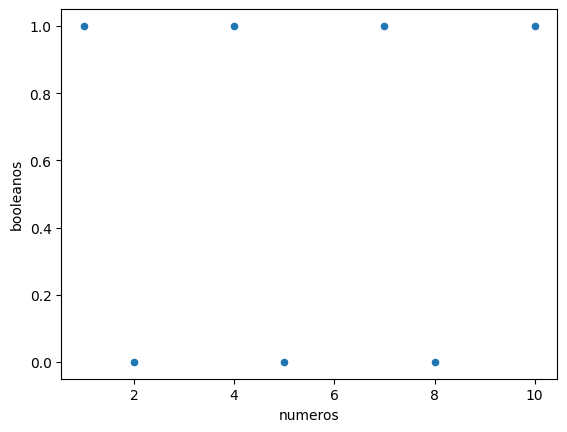

In [45]:
df.plot(x="numeros", y="booleanos", kind="scatter")